# Gut Spatial Transcriptomics — Data Loading and Exploration
## Replication and extension of Mayassi et al. 2024

This notebook loads the Visium spatial transcriptomics data from the 
Broad Single Cell Portal (SCP2762) and performs initial exploration.

**Dataset:** ~120,000 Visium spots spanning Duodenum, Jejunum1, Jejunum2, 
Ileum, and Colon from SPF, GF, and FMT mice.

## 1. Imports

In [20]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import os

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 1
print("All imports successful.")

All imports successful.


## 2. Define Paths

In [21]:
VISIUM_DIR = "/home/wojmor/studies/MODEL/gut_project/data/raw/visium"
FIGURES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/figures"
PROCESSED_DIR = "/home/wojmor/studies/MODEL/gut_project/data/processed"

# Create output dirs if they don't exist
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Paths set.")

Paths set.


## 3. Load Metadata and Spatial Coordinates


- `spatial_meta.tsv` — spot-level metadata (tissue region, microbe condition, donor)
- `spatial_cluster.tsv` — UMAP coordinates
- `unroll_cluster.tsv` — unrolled swiss-roll coordinates (X = proximal→distal axis, Y = crypt→villus axis)

In [22]:
# Load spatial metadata
spatial_meta = pd.read_csv(f"{VISIUM_DIR}/spatial_meta.tsv", sep="\t", index_col=0)
spatial_meta = spatial_meta[spatial_meta.index != 'TYPE']  # remove header artifact

# Load UMAP coordinates
spatial_umap = pd.read_csv(f"{VISIUM_DIR}/spatial_cluster.tsv", sep="\t", index_col=0, low_memory=False)
spatial_umap = spatial_umap[spatial_umap.index != 'TYPE']
spatial_umap[['X', 'Y']] = spatial_umap[['X', 'Y']].apply(pd.to_numeric, errors='coerce')

# Load unrolled coordinates
unroll = pd.read_csv(f"{VISIUM_DIR}/unroll_cluster.tsv", sep="\t", index_col=0, low_memory=False)
unroll = unroll[unroll.index != 'TYPE']
unroll[['X', 'Y']] = unroll[['X', 'Y']].apply(pd.to_numeric, errors='coerce')

print(f"Metadata: {spatial_meta.shape}")
print(f"UMAP:     {spatial_umap.shape}")
print(f"Unroll:   {unroll.shape}")

Metadata: (120021, 14)
UMAP:     (120021, 3)
Unroll:   (119285, 5)


## 4. Merge into a Single Dataframe

We merge all three tables on the spot barcode index for easy downstream use.

In [37]:
# Merge metadata + unroll coordinates
merged = unroll.join(spatial_meta[['tissue_region', 'microbe', 'donor_id']], how='inner')
merged = merged.dropna(subset=['X', 'Y'])

print(f"Merged dataframe shape: {merged.shape}")
print(f"\nTissue regions:\n{merged['tissue_region'].value_counts()}")
print(f"\nVillus layers:\n{merged['ylayer'].value_counts()}")
print(f"\nMicrobe conditions:\n{merged['microbe'].value_counts()}")

Merged dataframe shape: (119286, 8)

Tissue regions:
tissue_region
Jejunum1    28712
Jejunum2    26208
Duodenum    24448
Ileum       21105
Colon       18812
group           1
Name: count, dtype: int64

Villus layers:
ylayer
Top villous SI       49401
Bottom villous SI    18755
Crypt SI             16535
Muscle SI            15782
Crypt+LP colon        7414
Epi colon             5892
Muscle colon          5506
group                    1
Name: count, dtype: int64

Microbe conditions:
microbe
GF       48397
SPF      41123
FMT      29765
group        1
Name: count, dtype: int64


## 5. Define Color Schemes

Colors used throughout all figures.

In [52]:
REGION_COLORS = {
    'Duodenum':  '#1f77b4',
    'Jejunum1':  '#ff7f0e',
    'Jejunum2':  '#2ca02c',
    'Ileum':     '#d62728',
    'Colon':     '#9467bd',
}

LAYER_COLORS = {
    'Top villous SI':    '#e41a1c',
    'Bottom villous SI': '#ff7f00',
    'Crypt SI':          '#4daf4a',
    'Muscle SI':         '#984ea3',
    'Crypt+LP colon':    '#377eb8',
    'Epi colon':         '#a65628',
    'Muscle colon':      '#999999',
}

MICROBE_COLORS = {
    'SPF': '#2166ac',
    'GF':  '#d6604d',
    'FMT': '#4dac26',
}


## 6. Figure 1 — Spatial Overview of the Gut

The gut tissue is "unrolled" from its swiss-roll configuration into a 2D plane.
- **X axis**: proximal (duodenum) → distal (colon)
- **Y axis**: crypt base → villus tip

Left panel: colored by gut segment. Right panel: colored by tissue layer.

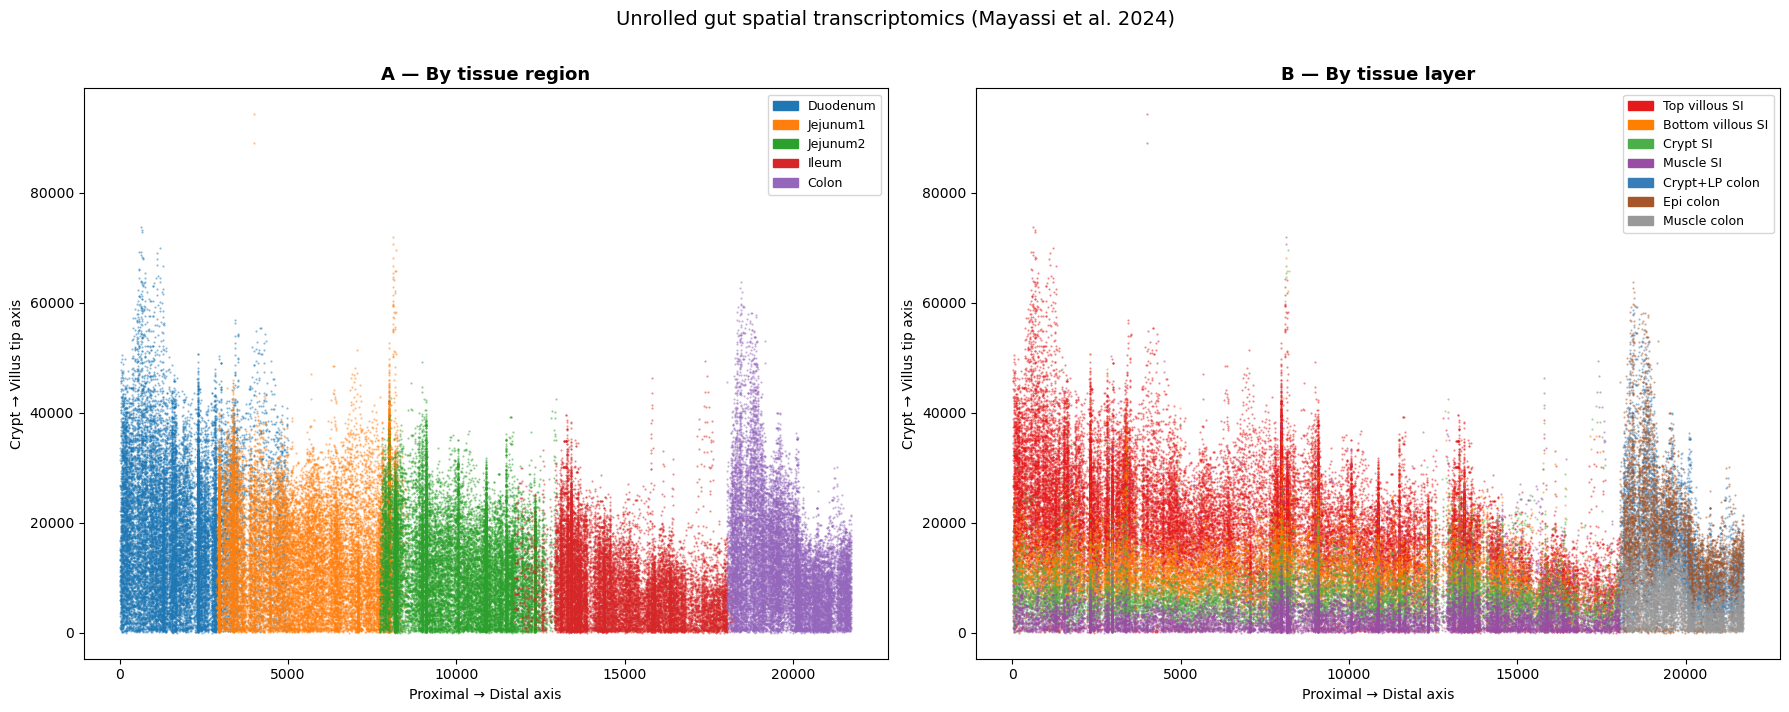

Figure 1 saved.


In [66]:
def make_legend(color_dict, ax, markerscale=8, fontsize=9):
    patches = [mpatches.Patch(color=c, label=l) for l, c in color_dict.items()]
    ax.legend(handles=patches, markerscale=markerscale, fontsize=fontsize)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: by tissue region
ax = axes[0]
for region, color in REGION_COLORS.items():
    mask = merged['tissue_region'] == region
    ax.scatter(merged.loc[mask, 'X'], merged.loc[mask, 'Y'],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('A — By tissue region', fontsize=13, fontweight='bold')
ax.set_xlabel('Proximal → Distal axis')
ax.set_ylabel('Crypt → Villus tip axis')
make_legend(REGION_COLORS, ax)

# Panel B: by tissue layer
ax = axes[1]
for layer, color in LAYER_COLORS.items():
    mask = merged['ylayer'] == layer
    ax.scatter(merged.loc[mask, 'X'], merged.loc[mask, 'Y'],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('B — By tissue layer', fontsize=13, fontweight='bold')
ax.set_xlabel('Proximal → Distal axis')
ax.set_ylabel('Crypt → Villus tip axis')
make_legend(LAYER_COLORS, ax)

plt.suptitle('Unrolled gut spatial transcriptomics (Mayassi et al. 2024)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_unrolled_gut_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")